# Exploring the data 

Load in all of the data and rasters that we have from the previous step. 

We'll focus on just the lowman data for now. 

In [43]:
import numpy as np

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

In [2]:
data_dir = '../data/' # on local machine
data_file = 'stacks/mores_creek/'

data = xr.open_zarr(data_dir + data_file)
# drop crs data var
data = data.drop_vars('crs')
print(data.data_vars)

Data variables:
    acq_day_precip      (pair, y, x) float64 87kB dask.array<chunksize=(21, 20, 25), meta=np.ndarray>
    aspect              (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    canopy_2019         (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    coherence           (pair, y, x) float32 44kB dask.array<chunksize=(21, 20, 25), meta=np.ndarray>
    cover_2019          (y, x) float64 4kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    curve               (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    density_change      (pair, y, x) float32 44kB dask.array<chunksize=(21, 20, 25), meta=np.ndarray>
    diurnal_temp_range  (pair, y, x) float64 87kB dask.array<chunksize=(21, 20, 25), meta=np.ndarray>
    elevation           (y, x) float32 2kB dask.array<chunksize=(20, 25), meta=np.ndarray>
    freeze_thaw_cycles  (pair, y, x) float64 87kB dask.array<chunksize=(21, 20, 25), meta=np.ndarray>
    hours_blowing_s

In [3]:
# nan mask 
nan_mask = np.isnan(data['coherence'].values).any(axis=0)  # axis=0 is the 'pair' dimension

# Now apply it universally to all variables
for var in data.data_vars:
    if 'x' in data[var].dims and 'y' in data[var].dims:
        data[var] = data[var].where(~nan_mask, drop=False)

Static variables: ['aspect', 'canopy_2019', 'cover_2019', 'curve', 'elevation', 'slope', 'snow_class']
Pair variables: ['acq_day_precip', 'coherence', 'density_change', 'diurnal_temp_range', 'freeze_thaw_cycles', 'hours_blowing_snow', 'max_temp', 'max_wind', 'mean_temp', 'mean_wind', 'swe_ablate', 'swe_accum', 'temp_diff', 'temp_diff_acq', 'total_posdeg', 'total_precip', 'total_rain', 'total_snow']


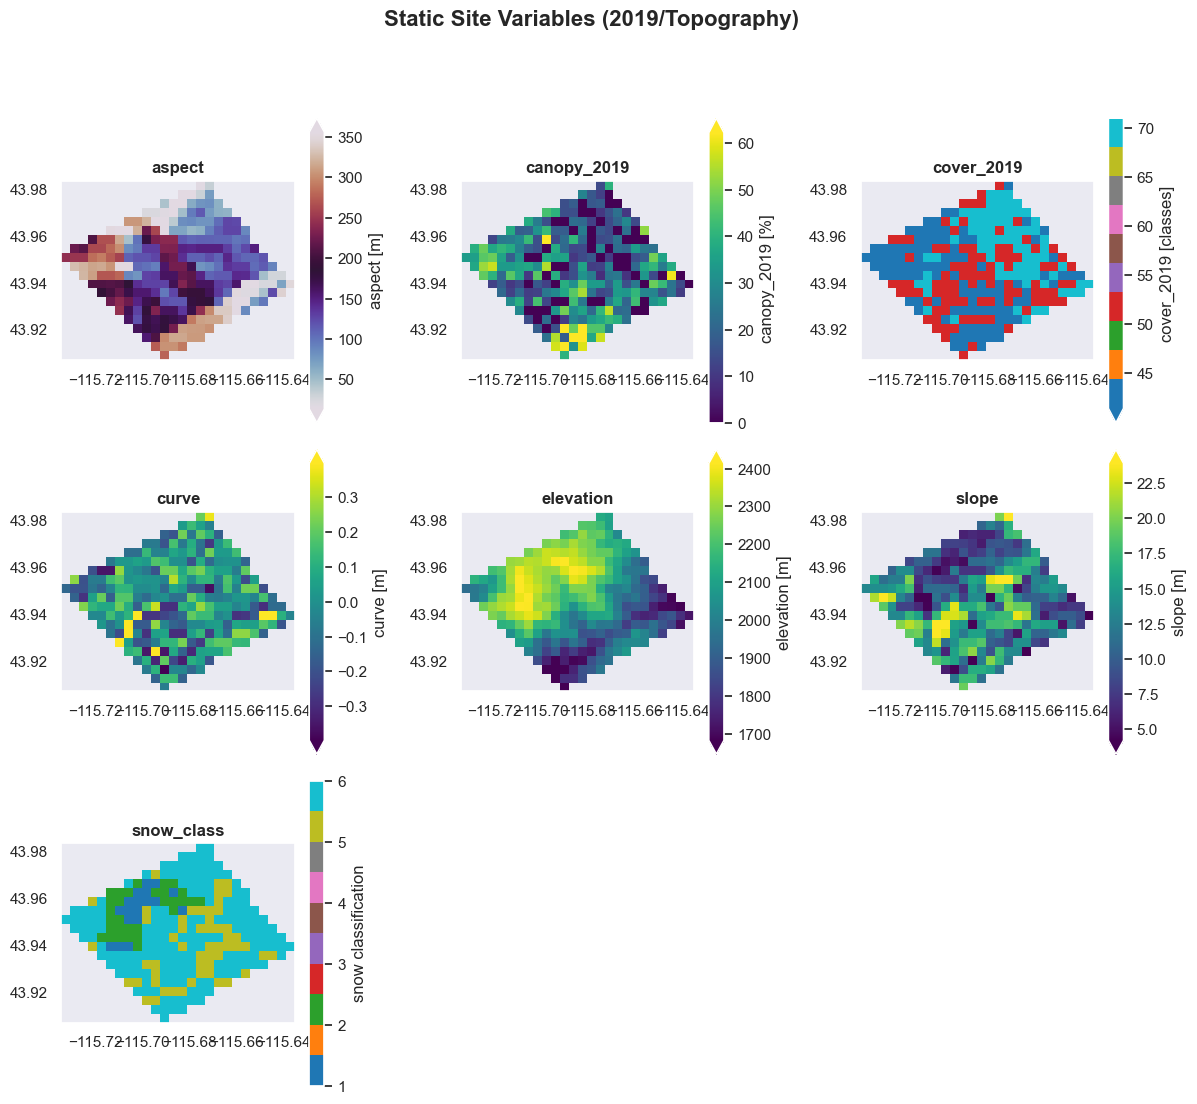

In [44]:
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
print("Static variables:", static_vars)
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]
print("Pair variables:", pair_vars)

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [29]:
# 3. Flatten into ML-ready format
data_array = data.to_array(dim='variable')  # (variable, pair, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

<xarray.DataArray (variable: 25, pair: 21, y: 20, x: 26)> Size: 2MB
dask.array<stack, shape=(25, 21, 20, 26), dtype=float64, chunksize=(1, 21, 20, 25), chunktype=numpy.ndarray>
Coordinates:
  * variable     (variable) object 200B 'acq_day_precip' ... 'total_snow'
  * pair         (pair) <U13 1kB '200131_200213' ... '210316_210322'
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
    band         int64 8B ...
    spatial_ref  int64 8B ...


,acq_day_precip,aspect,canopy_2019,coherence,cover_2019,curve,density_change,diurnal_temp_range,elevation,freeze_thaw_cycles,hours_blowing_snow,max_temp,max_wind,mean_temp,mean_wind,slope,snow_class,swe_ablate,swe_accum,temp_diff,temp_diff_acq,total_posdeg,total_precip,total_rain,total_snow
acq_day_precip,1.000000,0.005050,-0.003037,-0.006156,-0.001427,0.001408,0.136942,-0.289594,0.036854,-0.002928,0.368370,-0.202377,0.404729,-0.376789,0.270645,-0.008068,-0.022768,-0.044175,0.444678,-0.172056,-0.186709,-0.085331,0.459434,-0.140460,0.491760
aspect,0.005050,1.000000,0.374624,-0.154342,-0.369402,0.001067,0.041665,-0.119240,-0.018959,-0.000474,0.052005,-0.037907,0.096291,-0.001588,0.084327,0.043254,-0.068654,0.075558,0.056042,-0.016932,-0.010544,-0.007399,0.012528,0.004958,0.011538
canopy_2019,-0.003037,0.374624,1.000000,-0.114247,-0.563448,-0.061295,0.008835,-0.071408,-0.203450,0.004132,-0.039155,-0.019813,-0.006769,0.027868,-0.012343,0.022210,0.067658,0.033907,0.027294,-0.014725,-0.018461,0.018919,-0.001943,0.023657,-0.006989
coherence,-0.006156,-0.154342,-0.114247,1.000000,0.143480,0.045075,-0.329269,-0.026140,0.089512,-0.370068,-0.096530,-0.252427,-0.133279,-0.019274,0.040262,-0.000605,-0.022580,-0.159898,-0.333358,-0.080122,0.132180,-0.320978,-0.375367,-0.306844,-0.312025
cover_2019,-0.001427,-0.369402,-0.563448,0.143480,1.000000,0.150604,-0.049938,0.173856,0.130939,0.021848,-0.004174,0.071853,-0.072363,0.005769,-0.084852,-0.036577,-0.003863,-0.111574,-0.014719,0.027345,0.019855,0.032322,-0.008242,0.017380,-0.011986
curve,0.001408,0.001067,-0.061295,0.045075,0.150604,1.000000,-0.042676,0.025738,0.284723,-0.004856,0.051481,0.003158,0.039880,-0.024374,0.031668,-0.023143,-0.142857,-0.103237,0.017597,0.007315,0.011767,-0.014366,-0.000752,-0.021680,0.003860
density_change,0.136942,0.041665,0.008835,-0.329269,-0.049938,-0.042676,1.000000,0.322699,-0.160747,0.729768,0.154474,0.528320,0.128873,0.199477,-0.140267,0.048438,0.065919,0.456973,0.311696,0.291069,-0.038211,0.714796,0.367741,0.318166,0.301949
diurnal_temp_range,-0.289594,-0.119240,-0.071408,-0.026140,0.173856,0.025738,0.322699,1.000000,-0.412172,0.549228,-0.387066,0.783380,-0.540844,0.587837,-0.670946,-0.007424,0.329943,0.257510,-0.272072,0.360522,0.151636,0.644698,-0.245875,0.331873,-0.317823
elevation,0.036854,-0.018959,-0.203450,0.089512,0.130939,0.284723,-0.160747,-0.412172,1.000000,-0.329090,0.470243,-0.405110,0.496642,-0.431353,0.673674,-0.117944,-0.572270,-0.353340,0.147966,-0.009392,0.067172,-0.393626,0.055680,-0.405238,0.142243
freeze_thaw_cycles,-0.002928,-0.000474,0.004132,-0.370068,0.021848,-0.004856,0.729768,0.549228,-0.329090,1.000000,-0.116293,0.724986,-0.090382,0.421358,-0.417833,0.068648,0.234831,0.452243,0.221881,0.166558,-0.095596,0.893206,0.304497,0.689849,0.159245


In [58]:
# make a variable statistics table and print
stats_df = pd.DataFrame({
    'Variable': data.data_vars,
    'Min': [data[var].min().values for var in data.data_vars],
    'Max': [data[var].max().values for var in data.data_vars],
    'Mean': [data[var].mean().values for var in data.data_vars],
    'Std Dev': [data[var].std().values for var in data.data_vars]
})
# print with only 2 decimal places for readability
stats_df.style.format({'Min': '{:.3f}', 'Max': '{:.3f}', 'Mean': '{:.3f}', 'Std Dev': '{:.3f}'})


,Variable,Min,Max,Mean,Std Dev
0,acq_day_precip,0.000,0.800,0.173,0.311
1,aspect,0.254,357.689,171.638,94.928
2,canopy_2019,0.000,76.000,23.748,17.103
3,coherence,0.004,0.832,0.249,0.152
4,cover_2019,21.000,71.000,53.074,12.372
5,curve,-0.414,0.562,0.004,0.173
6,density_change,-0.055,0.257,0.053,0.037
7,diurnal_temp_range,4.088,11.829,7.274,1.403
8,elevation,1627.262,2438.426,2082.289,208.722
9,freeze_thaw_cycles,0.000,87.000,25.440,18.092


## Simple linear model 


R² score for linear regression: 0.274
RMSE for linear regression: 0.128
MSE for linear regression: 0.016


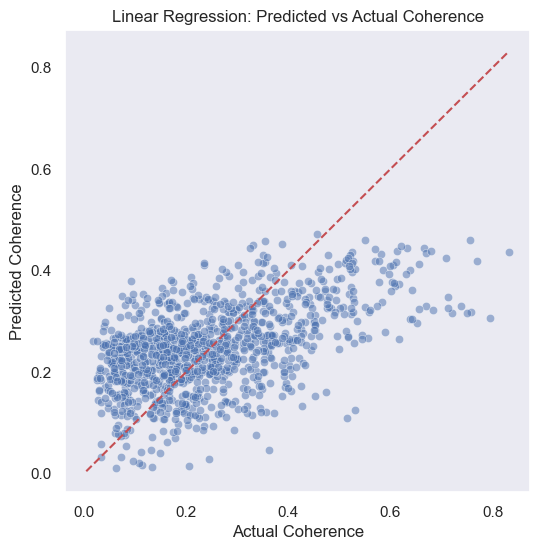

               Feature  Coefficient
10            max_temp    -4.29e-02
20        total_posdeg    -2.74e-02
22          total_rain    -2.73e-02
21        total_precip    -2.55e-02
6   diurnal_temp_range     2.48e-02
0       acq_day_precip     2.37e-02
11            max_wind    -2.25e-02
23          total_snow    -1.98e-02
8   freeze_thaw_cycles     1.75e-02
1               aspect    -1.41e-02
3           cover_2019     1.10e-02
9   hours_blowing_snow     1.10e-02
19       temp_diff_acq     7.88e-03
15          snow_class     5.45e-03
5       density_change    -5.36e-03
13           mean_wind     4.77e-03
17           swe_accum    -4.48e-03
2          canopy_2019    -4.37e-03
4                curve     4.08e-03
18           temp_diff     3.42e-03
14               slope     3.34e-03
7            elevation    -3.29e-03
12           mean_temp     1.78e-03
16          swe_ablate     1.53e-03


In [49]:
# linear model with sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# get column index of coherence 
c_idx = list(data.data_vars).index('coherence')
all_other_idxs = [i for i in range(len(data.data_vars)) if i != c_idx]

# Define features and target
X = data_clean[:, all_other_idxs]  # all variables except coherence
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R² score for linear regression: {r2:.3f}')
print(f'RMSE for linear regression: {rmse:.3f}')
print(f'MSE for linear regression: {mse:.3f}')

# Plot predicted vs actual coherence
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Linear Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()

# Feature importance (coefficients) from linear regression
feature_names = [v for v in data.data_vars if v != 'coherence']
coefficients = model.coef_
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
print(coef_df[['Feature', 'Coefficient']])


R² score for linear regression: 0.222
RMSE for linear regression: 0.132
MSE for linear regression: 0.018


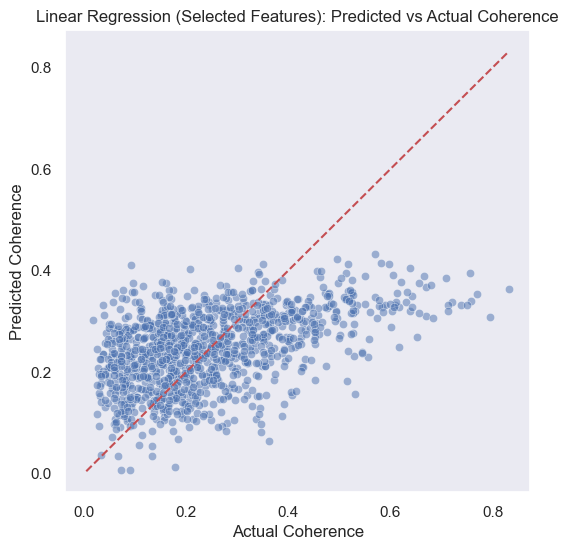

In [48]:
feature_subset = ['elevation', 
                  'slope', 
                  'aspect', 
                  'swe_accum', 
                  'cover_2019', 
                  'total_posdeg', 
                  'mean_temp',
                  'max_wind']
subset_idxs = [list(data.data_vars).index(var) for var in feature_subset]

# Define features and target
X = data_clean[:, subset_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R² score for linear regression: {r2:.3f}')
print(f'RMSE for linear regression: {rmse:.3f}')
print(f'MSE for linear regression: {mse:.3f}')

# Plot predicted vs actual coherence
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Linear Regression (Selected Features): Predicted vs Actual Coherence')
plt.grid()
plt.show()

# Simple decision tree

R² score for decision tree regression: 0.143
RMSE for decision tree regression: 0.139
MSE for decision tree regression: 0.019


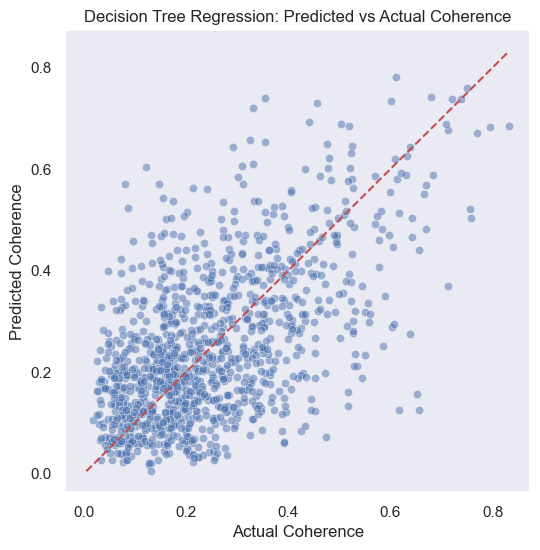

               Feature  Importance
21        total_precip    2.04e-01
22          total_rain    1.65e-01
1               aspect    8.23e-02
5       density_change    5.57e-02
7            elevation    5.01e-02
4                curve    4.85e-02
14               slope    4.68e-02
17           swe_accum    4.25e-02
2          canopy_2019    3.70e-02
0       acq_day_precip    3.45e-02
10            max_temp    3.45e-02
13           mean_wind    2.62e-02
19       temp_diff_acq    2.43e-02
20        total_posdeg    2.31e-02
23          total_snow    2.04e-02
6   diurnal_temp_range    1.70e-02
16          swe_ablate    1.63e-02
3           cover_2019    1.37e-02
12           mean_temp    1.31e-02
11            max_wind    1.12e-02
18           temp_diff    9.40e-03
9   hours_blowing_snow    9.34e-03
8   freeze_thaw_cycles    7.27e-03
15          snow_class    7.15e-03


In [51]:
# make a decision tree regressor and evaluate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# redefine features and target for decision tree
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train decision tree regressor
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_tree = tree_model.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = root_mean_squared_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
print(f'R² score for decision tree regression: {r2_tree:.3f}')
print(f'RMSE for decision tree regression: {rmse_tree:.3f}')
print(f'MSE for decision tree regression: {mse_tree:.3f}')

# Plot predicted vs actual coherence for decision tree
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title('Decision Tree Regression: Predicted vs Actual Coherence')
plt.grid()
plt.show()  

# Feature importance from decision tree
feature_names = [v for v in data.data_vars if v != 'coherence']
importances = tree_model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
print(importance_df)


# Random forest

R² score for random forest regression: 0.532
RMSE for random forest regression: 0.103
MSE for random forest regression: 0.011


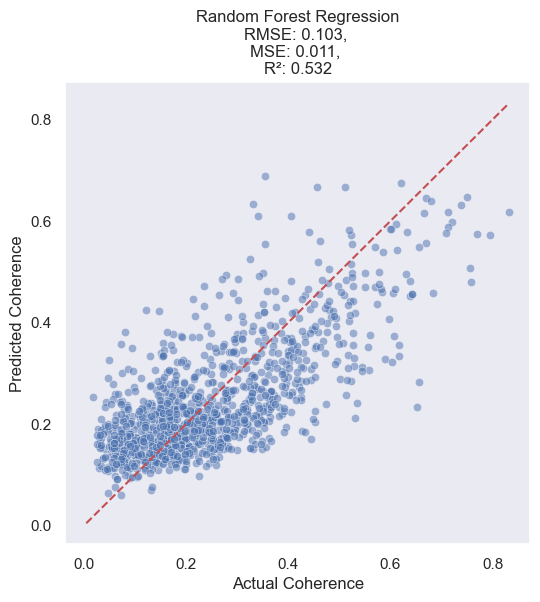

               Feature  Importance
21        total_precip    2.07e-01
22          total_rain    1.65e-01
1               aspect    7.26e-02
5       density_change    5.83e-02
7            elevation    4.98e-02
14               slope    4.80e-02
4                curve    4.60e-02
17           swe_accum    4.04e-02
2          canopy_2019    3.69e-02
10            max_temp    3.09e-02
20        total_posdeg    3.08e-02
19       temp_diff_acq    2.71e-02
13           mean_wind    2.49e-02
23          total_snow    2.37e-02
16          swe_ablate    2.10e-02
0       acq_day_precip    1.89e-02
11            max_wind    1.60e-02
18           temp_diff    1.50e-02
12           mean_temp    1.47e-02
6   diurnal_temp_range    1.43e-02
8   freeze_thaw_cycles    1.20e-02
3           cover_2019    9.91e-03
9   hours_blowing_snow    9.61e-03
15          snow_class    6.90e-03


In [59]:
# make a random forest model and evaluate
from sklearn.ensemble import RandomForestRegressor

# redefine features and target for random forest
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train random forest regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'R² score for random forest regression: {r2_rf:.3f}')
print(f'RMSE for random forest regression: {rmse_rf:.3f}')
print(f'MSE for random forest regression: {mse_rf:.3f}')

# Plot predicted vs actual coherence for random forest
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title(f'Random Forest Regression\nRMSE: {rmse_rf:.3f}, \nMSE: {mse_rf:.3f}, \nR²: {r2_rf:.3f}')
plt.grid()
plt.show() 

# Feature importance from random forest
feature_names = [v for v in data.data_vars if v != 'coherence']
importances_rf = rf_model.feature_importances_
importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
importance_rf_df = importance_rf_df.sort_values('Importance', ascending=False)
print(importance_rf_df)

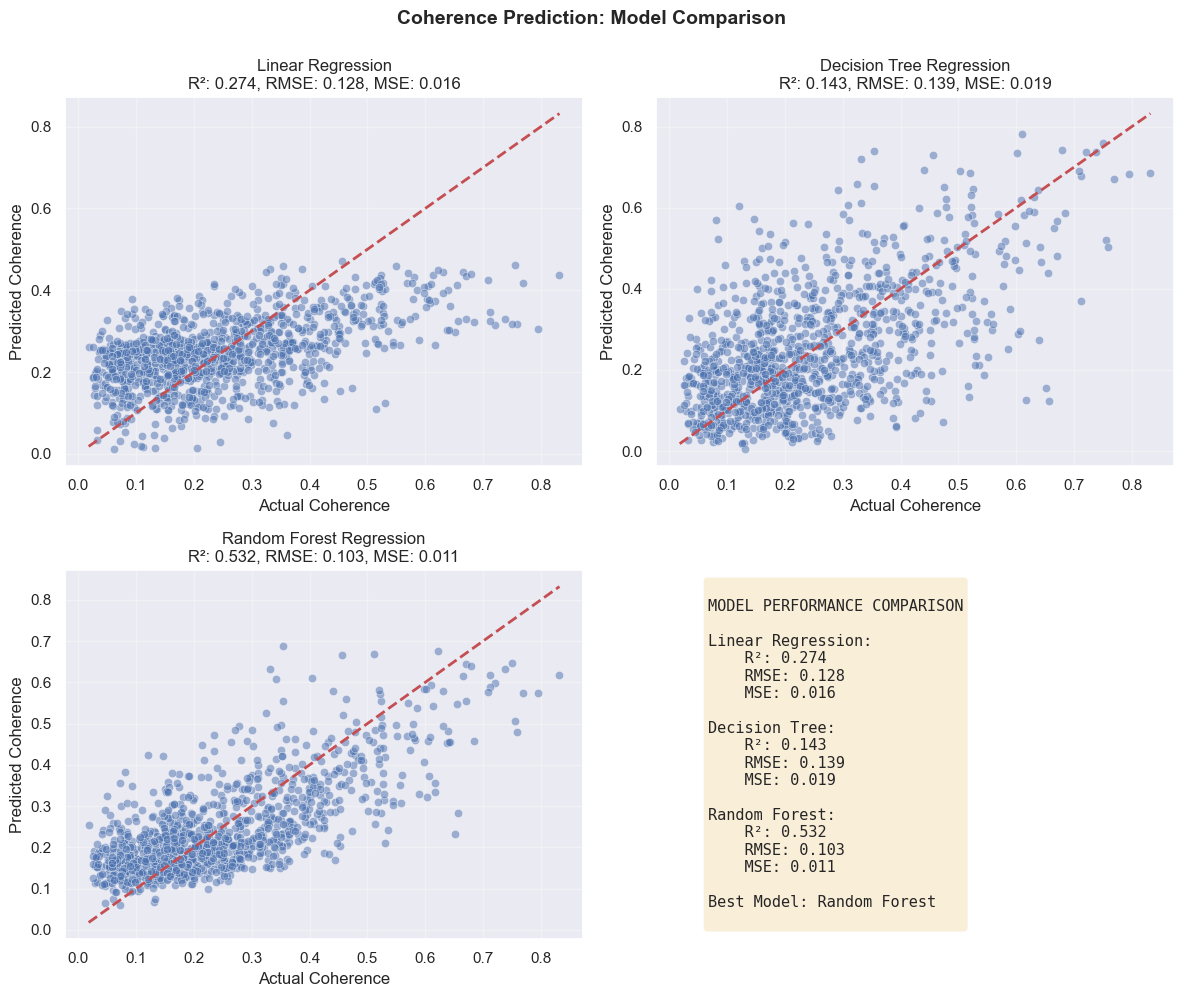

In [60]:
# Create a figure with 4 subplots for model comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 1. Linear Regression
ax = axes[0]
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Linear Regression\nR²: {r2:.3f}, RMSE: {rmse:.3f}, MSE: {mse:.3f}')
ax.grid(True, alpha=0.3)

# 2. Decision Tree
ax = axes[1]
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Decision Tree Regression\nR²: {r2_tree:.3f}, RMSE: {rmse_tree:.3f}, MSE: {mse_tree:.3f}')
ax.grid(True, alpha=0.3)

# 3. Random Forest
ax = axes[2]
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Coherence')
ax.set_ylabel('Predicted Coherence')
ax.set_title(f'Random Forest Regression\nR²: {r2_rf:.3f}, RMSE: {rmse_rf:.3f}, MSE: {mse_rf:.3f}')
ax.grid(True, alpha=0.3)

# 4. Model Comparison Summary (text plot)
ax = axes[3]
ax.axis('off')
summary_text = f"""
MODEL PERFORMANCE COMPARISON

Linear Regression:
    R²: {r2:.3f}
    RMSE: {rmse:.3f}
    MSE: {mse:.3f}

Decision Tree:
    R²: {r2_tree:.3f}
    RMSE: {rmse_tree:.3f}
    MSE: {mse_tree:.3f}

Random Forest:
    R²: {r2_rf:.3f}
    RMSE: {rmse_rf:.3f}
    MSE: {mse_rf:.3f}

Best Model: Random Forest
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Coherence Prediction: Model Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

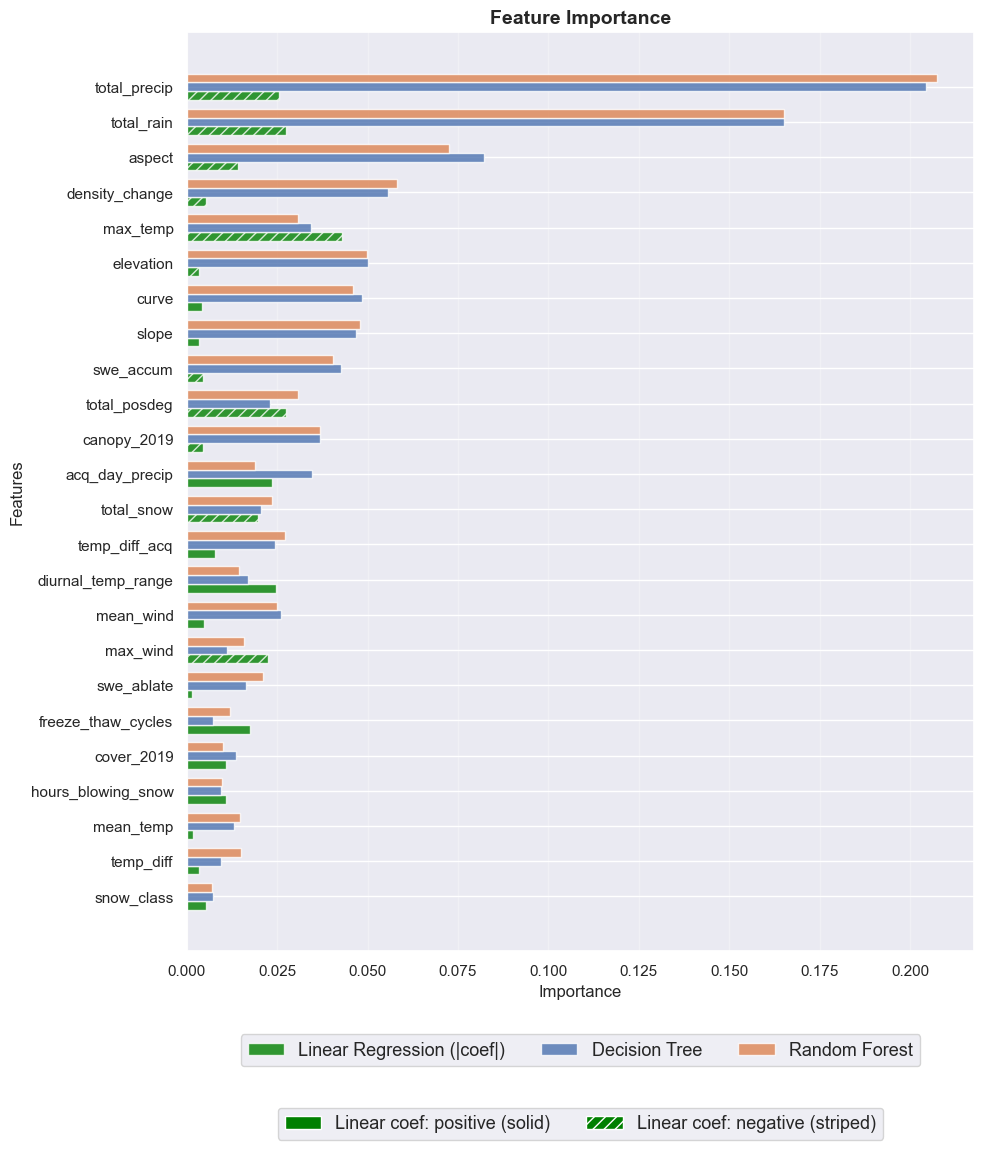


Feature Importance Comparison (sorted by mean importance):
           Feature  Linear Coef Linear Sign  Linear Regression  Decision Tree  Random Forest  Mean Importance
        snow_class     5.45e-03    Positive           5.45e-03       7.15e-03       6.90e-03         6.50e-03
         temp_diff     3.42e-03    Positive           3.42e-03       9.40e-03       1.50e-02         9.29e-03
         mean_temp     1.78e-03    Positive           1.78e-03       1.31e-02       1.47e-02         9.86e-03
hours_blowing_snow     1.10e-02    Positive           1.10e-02       9.34e-03       9.61e-03         9.97e-03
        cover_2019     1.10e-02    Positive           1.10e-02       1.37e-02       9.91e-03         1.15e-02
freeze_thaw_cycles     1.75e-02    Positive           1.75e-02       7.27e-03       1.20e-02         1.23e-02
        swe_ablate     1.53e-03    Positive           1.53e-03       1.63e-02       2.10e-02         1.29e-02
          max_wind    -2.25e-02    Negative           2.25e-

In [69]:
# Create a comparison of feature importances across models
# Keep signed linear coefficients for direction, and absolute values for ranking
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Coef': coefficients,
    'Linear Regression': np.abs(coefficients),
    'Decision Tree': importances,
    'Random Forest': importances_rf
})

# Add sign label for linear model direction
comparison_df['Linear Sign'] = np.where(comparison_df['Linear Coef'] >= 0, 'Positive', 'Negative')

# Calculate mean importance across all models to order features
comparison_df['Mean Importance'] = comparison_df[['Linear Regression', 'Decision Tree', 'Random Forest']].mean(axis=1)
comparison_df = comparison_df.sort_values('Mean Importance', ascending=True)

# Create horizontal bar plot for easier feature name readability
fig, ax = plt.subplots(figsize=(10, 12))

x = np.arange(len(comparison_df))
width = 0.25

# Draw linear bars with one color; use fill pattern to indicate sign
linear_bars = ax.barh(
    x - width,
    comparison_df['Linear Regression'],
    width,
    color='green',
    # edgecolor='black',
    alpha=0.8,
    label='Linear Regression (|coef|)'
)

# Solid hatch for positive, striped hatch for negative
for bar, coef in zip(linear_bars, comparison_df['Linear Coef']):
    bar.set_hatch('' if coef >= 0 else '///')

ax.barh(x, comparison_df['Decision Tree'], width, label='Decision Tree', alpha=0.8)
ax.barh(x + width, comparison_df['Random Forest'], width, label='Random Forest', alpha=0.8)

# Sign legend for linear regression fill style
from matplotlib.patches import Patch
sign_legend = [
    Patch(facecolor='green', hatch='', label='Linear coef: positive (solid)'),
    Patch(facecolor='green', hatch='///', label='Linear coef: negative (striped)')
]

ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax.set_yticks(x)
ax.set_yticklabels(comparison_df['Feature'])

# Stack both legends at the bottom and increase legend text size
legend_models = ax.legend(
    fontsize=13,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=True
)
ax.add_artist(legend_models)
ax.legend(
    handles=sign_legend,
    fontsize=13,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    frameon=True
)

ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# Print the comparison table with sign information
print("\nFeature Importance Comparison (sorted by mean importance):")
print(comparison_df[['Feature', 'Linear Coef', 'Linear Sign', 'Linear Regression', 'Decision Tree', 'Random Forest', 'Mean Importance']].to_string(index=False))